# **PITP Certified Data Scientist Program**

*   *Final Project*
*   *Submitted By Muhammad Shayan Haider*

# 🧩 **1. Project Introduction**

# 🧠 Customer Churn Prediction

This project predicts whether a telecom customer is likely to leave the service (churn) based on their demographic and usage details.

### 🎯 Objective:
To build machine learning models that classify customers as “Churn” or “Not Churn” using various algorithms.

### 📊 Dataset:
We’ll use the **Telco Customer Churn dataset**, which contains information about:
- Customer demographics
- Account information
- Services subscribed
- Churn status (target variable)

**Target column:** `Churn`


# 🗂️ **2. Import Required Libraries**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 🗂️ **3. Load Dataset**
### Load the Customer Churn dataset and view basic details.

In [25]:
df = pd.read_csv("Customer-Churn.csv")
print("Dataset Shape: ", df.shape)
print("\nFirst 5 Rows: \n",df.head())

Dataset Shape:  (7043, 21)

First 5 Rows: 
    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport Stre

# 🔍 **3. Basic Info and Missing Values**
### Check data types, null values, and clean incorrect values.

In [3]:
print("Dataset Info:\n")
df.info()

print("\nMissing Values:\n", df.isnull().sum())

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-

In [4]:
print("Data Types: ", df.dtypes)

Data Types:  customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [5]:
# Convert TotalCharges to numeric and fill missing values.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

/tmp/ipython-input-438484328.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


# 🗑️ **4. Drop Irrelevant Columns**
### Remove columns that don’t contribute to prediction.

In [6]:
df.drop(['customerID'], axis=1, inplace=True)

# 🔠 **5. Encode Categorical Columns**
### Convert categorical text columns into numeric form using LabelEncoder.

In [7]:
cat_cols = df.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# 🎯 **6. Split Features and Target**
### Separate input features (X) and target variable (y).

In [8]:
X = df.drop('Churn', axis=1)
y = df['Churn']

# ⚖️ **7. Feature Scaling**
### Standardize numerical values to balance all feature scales.

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ✂️ **8. Train-Test Split**
### Divide data into training (80%) and testing (20%) sets.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print("Training Samples:", X_train.shape[0], "| Testing Samples:", X_test.shape[0])

Training Samples: 5634 | Testing Samples: 1409


# 🧠 **9. Model Training**
### Train Logistic Regression, Decision Tree, and Random Forest and K-Nearest Neighbor models.

In [12]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

rf = RandomForestClassifier(random_state=42, n_estimators=200)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

# 📊 **10. Model Evaluation**
### Evaluate all models using accuracy, precision, recall, and F1-score.

In [13]:
models = {
    'Logistic Regression': lr_pred,
    'Decision Tree': dt_pred,
    'Random Forest': rf_pred,
    'K-Nearest Neighbors': knn_pred
}

print("\n===== MODEL PERFORMANCE =====")
for name, pred in models.items():
    print(f"\n{name}")
    print("Accuracy:", round(accuracy_score(y_test, pred)*100, 2), "%")
    print(classification_report(y_test, pred))


===== MODEL PERFORMANCE =====

Logistic Regression
Accuracy: 81.55 %
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409


Decision Tree
Accuracy: 72.46 %
              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1036
           1       0.48      0.51      0.49       373

    accuracy                           0.72      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.72      0.73      1409


Random Forest
Accuracy: 79.91 %
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.67      0.48      0.56       373

    accuracy                           0.80   

# 🧮 **11. Confusion Matrix for Best Model**
### Visualize prediction accuracy using a confusion matrix for Random Forest.

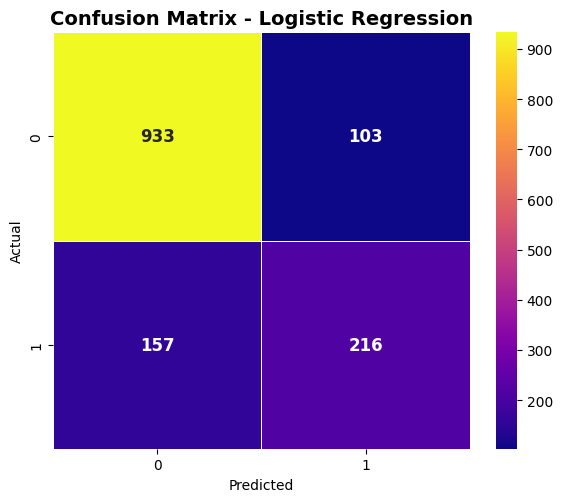

In [15]:
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='plasma',
    cbar=True,
    square=True,
    linewidths=0.5,
    annot_kws={"size":12, "weight":"bold"}
)
plt.title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# 🌳 **12. Feature Importance (Random Forest)**
### Display top 10 most influential features affecting churn.

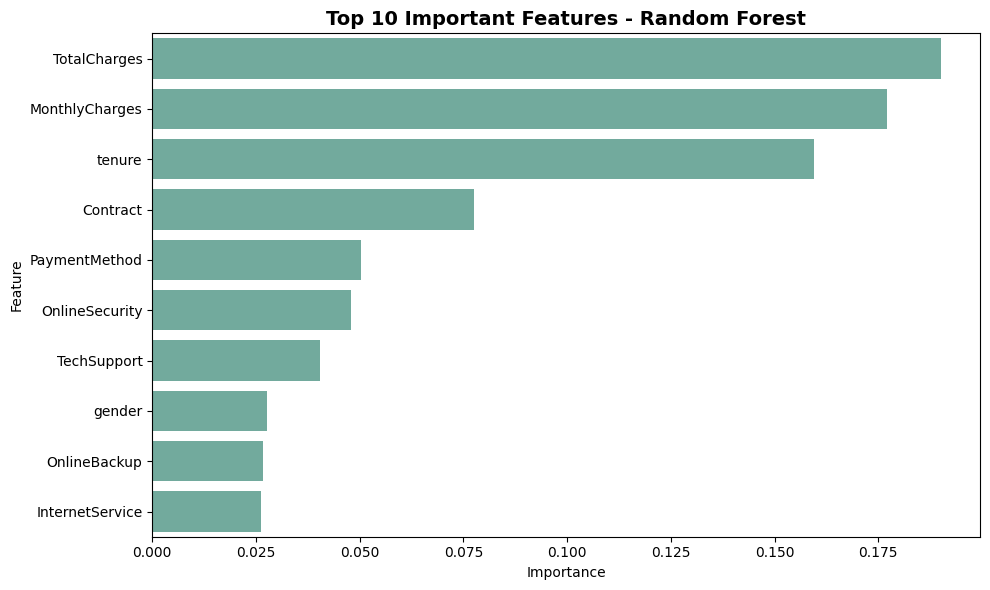

In [17]:
feature_importances = rf.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

top_features = importance_df.head(10)

plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features,
    color="#69b3a2"
)

plt.title('Top 10 Important Features - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# 📈 **13. Visualization (EDA)**
### Explore churn distribution and key feature relationships visually.

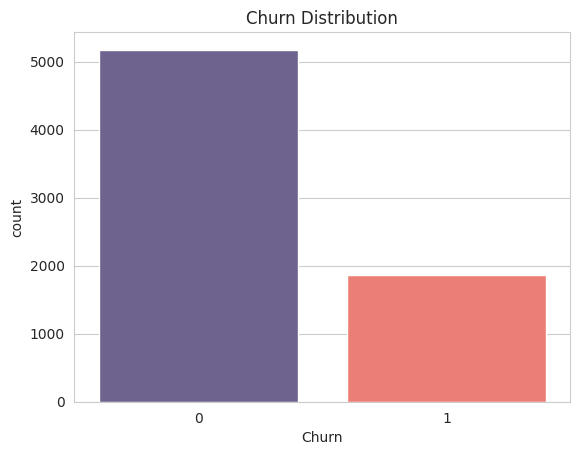

In [18]:
sns.set_style("whitegrid")
sns.countplot(data=df, x='Churn', hue='Churn', palette={0:"#6B5B95", 1:"#FF6F61"}, legend=False)
plt.title('Churn Distribution')
plt.show()

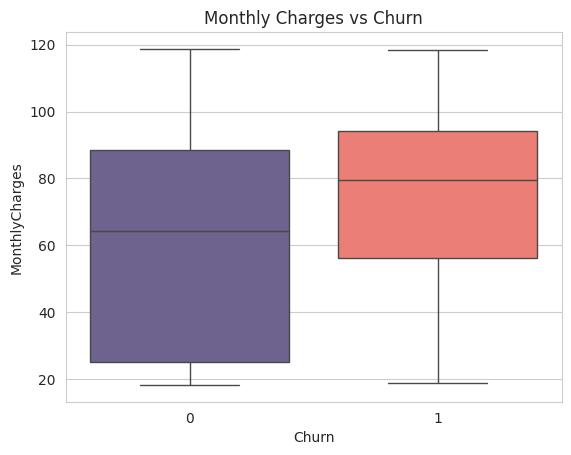

In [19]:
sns.set_style("whitegrid")
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, hue='Churn', palette={0:"#6B5B95", 1:"#FF6F61"}, legend=False)
plt.title('Monthly Charges vs Churn')
plt.show()

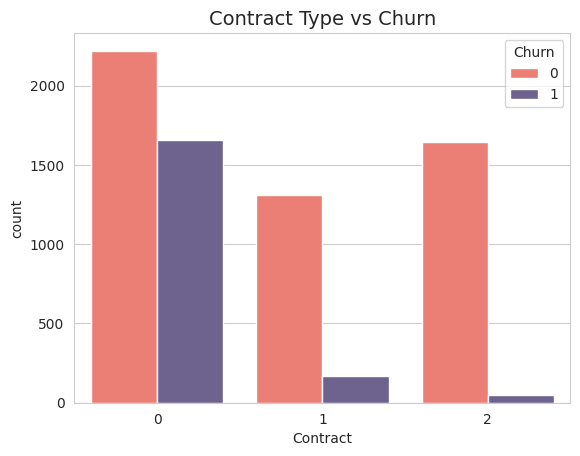

In [20]:
sns.set_style("whitegrid")
sns.countplot(x='Contract', hue='Churn', data=df, palette={0:"#FF6F61",1:"#6B5B95"})
plt.title('Contract Type vs Churn', fontsize=14)
plt.show()

# ✅ **14. Final Summary**
### Display best model results and most influential features.

In [21]:
print("✅ Project Completed Successfully!\n")
print("Best Performing Model (Expected): Logistic Regression")
print("Key Influencing Features:", list(importance_df.head(5)['Feature']))

✅ Project Completed Successfully!

Best Performing Model (Expected): Logistic Regression
Key Influencing Features: ['TotalCharges', 'MonthlyCharges', 'tenure', 'Contract', 'PaymentMethod']


#  🔮 **15. Predict New Customer**
### Allow user to enter new customer data manually.

In [27]:
print("\n🔹 Enter details of a new customer below:")

# Take numeric input
tenure = float(input("Tenure in months (e.g. 12): "))
monthly_charges = float(input("Monthly Charges (e.g. 70.5): "))
total_charges = float(input("Total Charges (e.g. 845.0): "))

# Create DataFrame with these inputs
new_customer = pd.DataFrame({
    'tenure': [tenure],
    'MonthlyCharges': [monthly_charges],
    'TotalCharges': [total_charges]
})

# Reindex to match training features (fill missing columns with 0)
new_customer = new_customer.reindex(columns=X.columns, fill_value=0)

# Scale using the same scaler
new_scaled = scaler.transform(new_customer)

# Model selection menu
print("\nSelect model for prediction:")
print("1. Logistic Regression")
print("2. Decision Tree")
print("3. Random Forest")
print("4. K-Nearest Neighbors")
choice = input("Enter choice (1/2/3/4): ")

# Map choice to model
if choice == '1':
    selected_model = lr
elif choice == '2':
    selected_model = dt # Changed from dtree to dt
elif choice == '3':
    selected_model = rf
elif choice == '4':
    selected_model = knn
else:
    print("Invalid choice, defaulting to Random Forest.")
    selected_model = rf

# Predict
pred = selected_model.predict(new_scaled)
prob = selected_model.predict_proba(new_scaled)[0][1]

if prob < 0.30:
    result = "Unlikely to churn"
elif prob < 0.60:
    result = "At risk of churn"
else:
    result = "Likely to churn"

# Print result
print(f"\n🔍 Churn Prediction: {result} (Probability: {prob*100:.2f}%)")


🔹 Enter details of a new customer below:
Tenure in months (e.g. 12): 1
Monthly Charges (e.g. 70.5): 30.5
Total Charges (e.g. 845.0): 200.5

Select model for prediction:
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. K-Nearest Neighbors
Enter choice (1/2/3/4): 2

🔍 Churn Prediction: Unlikely to churn (Probability: 0.00%)


# ✅ **Project Summary**

- The dataset was cleaned, encoded, and scaled.
- Four ML models were trained for churn prediction: Logistic Regression, Decision Tree, Random Forest, and KNN.
- Random Forest and Logistic Regression showed the best performance.
- The script allows:
  - Viewing the dataset and comparing model performance
  - Predicting churn for new individual customers via input prompts

### 💡 Outcome
Helps telecom companies identify customers likely to leave and take retention actions proactively.
